# Семестровая работа: сортировка пузырьком

Практическая часть: реализация базового и модифицированного пузырька, демонстрация шагов для заданных списков и проведение вычислительных экспериментов.


In [1]:
import random
import matplotlib.pyplot as plt
from time import perf_counter

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

# --- Сортировки ---
def bubble_sort(a):
    comps = swaps = 0
    for end in range(len(a) - 1, 0, -1):
        moved = False
        for i in range(end):
            comps += 1
            if a[i] > a[i + 1]:
                a[i], a[i + 1] = a[i + 1], a[i]
                swaps += 1
                moved = True
        if not moved:
            break
    return comps, swaps


def bubble_sort_trace(a):
    a = a.copy()
    states, comps, swaps = [], 0, 0
    for end in range(len(a) - 1, 0, -1):
        moved = False
        for i in range(end):
            comps += 1
            if a[i] > a[i + 1]:
                a[i], a[i + 1] = a[i + 1], a[i]
                swaps += 1
                moved = True
        states.append(a.copy())
        if not moved:
            break
    return states, comps, swaps


def bubble_sort_mod(a):
    comps = swaps = 0
    l, r = 0, len(a) - 1
    while l < r:
        new_r = l
        for i in range(l, r):
            comps += 1
            if a[i] > a[i + 1]:
                a[i], a[i + 1] = a[i + 1], a[i]
                swaps += 1
                new_r = i
        r = new_r
        if l >= r:
            break
        new_l = r
        for i in range(r, l, -1):
            comps += 1
            if a[i - 1] > a[i]:
                a[i], a[i - 1] = a[i - 1], a[i]
                swaps += 1
                new_l = i
        l = new_l
    return comps, swaps


# --- Генераторы данных ---
def gen_random(n):
    return [random.randint(0, 10_000) for _ in range(n)]


def gen_sorted(n):
    return list(range(n))


def gen_almost_reversed(n):
    a = list(range(n, 0, -1))
    if n > 2:
        mid = n // 2
        a[mid], a[mid - 1] = a[mid - 1], a[mid]
    return a


def gen_half01(n):
    a = [0] * (n // 2) + [1] * (n - n // 2)
    random.shuffle(a)
    return a


def gen_noise(n, ratio=0.05):
    a = list(range(n))
    for _ in range(max(1, int(n * ratio))):
        i, j = random.randint(0, n - 1), random.randint(0, n - 1)
        a[i], a[j] = a[j], a[i]
    return a


generators = {
    "random": gen_random,
    "sorted": gen_sorted,
    "almost_reversed": gen_almost_reversed,
    "half01": gen_half01,
    "noise5%": gen_noise,
}


# --- Замеры ---
def measure(sort_fn, gen_fn, sizes, repeats=3):
    stats = []
    for n in sizes:
        time_sum = comps_sum = swaps_sum = 0
        for _ in range(repeats):
            data = gen_fn(n)
            start = perf_counter()
            comps, swaps = sort_fn(data)
            time_sum += perf_counter() - start
            comps_sum += comps
            swaps_sum += swaps
        stats.append({
            "n": n,
            "time": time_sum / repeats,
            "comps": comps_sum // repeats,
            "swaps": swaps_sum // repeats,
        })
    return stats


In [2]:
def show_trace(initial):
    data = initial.copy()
    states, comps, swaps = bubble_sort_trace(data)
    print(f"Старт: {initial}")
    for step, state in enumerate(states, 1):
        print(f"После итерации {step}: {state}")
    print(f"Сравнений: {comps}, перестановок: {swaps}\n")

    return states, comps, swaps


## Задача 1: трассировка списка [7, 3, 9, 4, 2, 5, 6, 1, 8]

In [3]:
trace1, comps1, swaps1 = show_trace([7, 3, 9, 4, 2, 5, 6, 1, 8])


Старт: [7, 3, 9, 4, 2, 5, 6, 1, 8]
После итерации 1: [3, 7, 4, 2, 5, 6, 1, 8, 9]
После итерации 2: [3, 4, 2, 5, 6, 1, 7, 8, 9]
После итерации 3: [3, 2, 4, 5, 1, 6, 7, 8, 9]
После итерации 4: [2, 3, 4, 1, 5, 6, 7, 8, 9]
После итерации 5: [2, 3, 1, 4, 5, 6, 7, 8, 9]
После итерации 6: [2, 1, 3, 4, 5, 6, 7, 8, 9]
После итерации 7: [1, 2, 3, 4, 5, 6, 7, 8, 9]
После итерации 8: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Сравнений: 36, перестановок: 19



## Задача 2: трассировка списка [3, 5, 2, 9, 8, 1, 6, 4, 7]


In [4]:
trace2, comps2, swaps2 = show_trace([3, 5, 2, 9, 8, 1, 6, 4, 7])


Старт: [3, 5, 2, 9, 8, 1, 6, 4, 7]
После итерации 1: [3, 2, 5, 8, 1, 6, 4, 7, 9]
После итерации 2: [2, 3, 5, 1, 6, 4, 7, 8, 9]
После итерации 3: [2, 3, 1, 5, 4, 6, 7, 8, 9]
После итерации 4: [2, 1, 3, 4, 5, 6, 7, 8, 9]
После итерации 5: [1, 2, 3, 4, 5, 6, 7, 8, 9]
После итерации 6: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Сравнений: 33, перестановок: 16



## Асимптотическая сложность

Базовый пузырёк: худший и средний случай — O(n^2) сравнений и обменов, лучший (уже отсортирован) — O(n) сравнений и 0 обменов.

Память: O(1) дополнительной памяти, так как сортировка выполняется на месте.

Модифицированный вариант сохраняет тот же порядок сложности, но чаще останавливается раньше и уменьшает диапазон поиска при почти отсортированных данных.


## Эксперименты производительности

Замеряем время работы обеих реализаций для размеров n = 100, 500, 1000, 2000, 4000, 6000, 8000, 10000 на пяти типах входных данных.


In [5]:
sizes = [100, 500, 1000, 2000, 4000, 6000, 8000, 10_000]
repeats = 3


def run_experiments(sizes, repeats=3):
    results = {}
    for name, gen in generators.items():
        results[name] = {
            "classic": measure(bubble_sort, gen, sizes, repeats),
            "modified": measure(bubble_sort_mod, gen, sizes, repeats),
        }
    return results


experiments = run_experiments(sizes, repeats)
experiments


{'random': {'classic': [{'n': 100,
    'time': 0.00024339999981748406,
    'comps': 4890,
    'swaps': 2454},
   {'n': 500, 'time': 0.007017733333365565, 'comps': 124146, 'swaps': 62272},
   {'n': 1000, 'time': 0.0321143666660646, 'comps': 498251, 'swaps': 244189},
   {'n': 2000,
    'time': 0.12977456666703802,
    'comps': 1998289,
    'swaps': 1011846},
   {'n': 4000, 'time': 0.5288018666669814, 'comps': 7994739, 'swaps': 3988487},
   {'n': 6000, 'time': 1.169873433333123, 'comps': 17985706, 'swaps': 8938286},
   {'n': 8000,
    'time': 2.183681099999376,
    'comps': 31983977,
    'swaps': 16111599},
   {'n': 10000,
    'time': 3.3614923666664254,
    'comps': 49981847,
    'swaps': 24983689}],
  'modified': [{'n': 100,
    'time': 0.00020060000012260085,
    'comps': 3441,
    'swaps': 2541},
   {'n': 500, 'time': 0.005592400000144456, 'comps': 84535, 'swaps': 62532},
   {'n': 1000, 'time': 0.023820799999157316, 'comps': 330935, 'swaps': 247150},
   {'n': 2000, 'time': 0.100865400

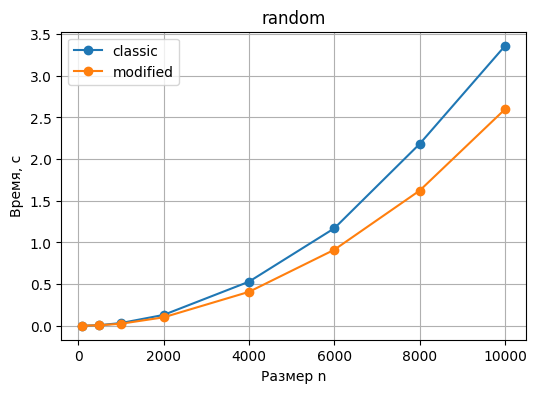

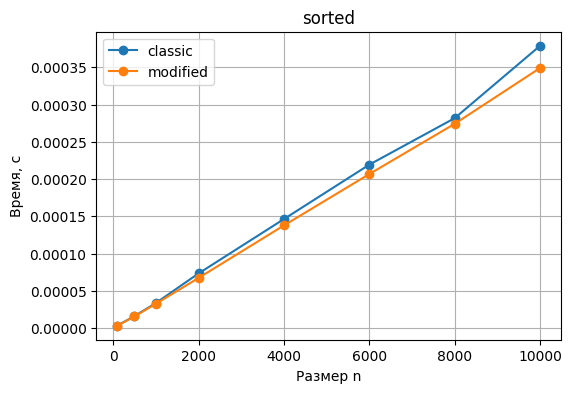

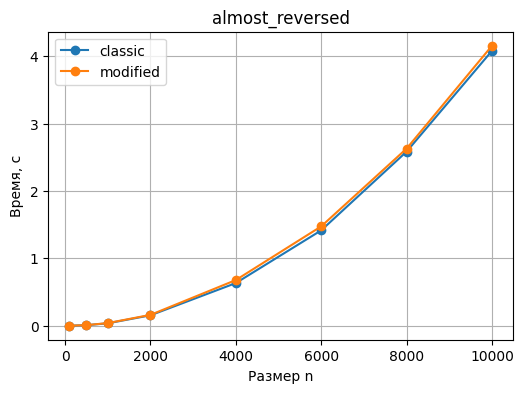

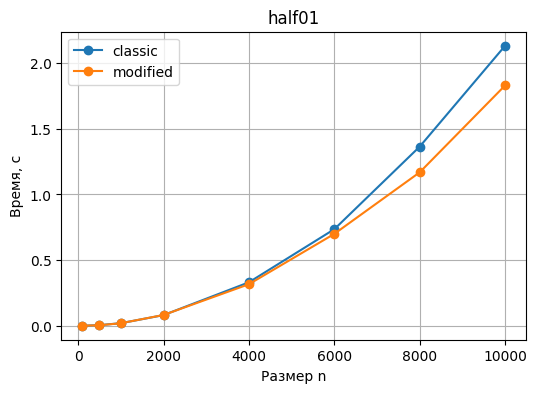

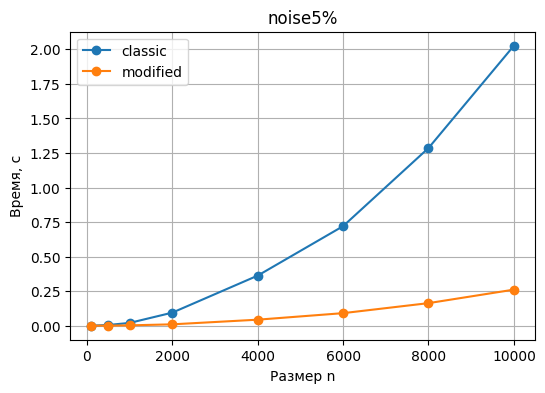

In [6]:
def plot_case(case_name, case_results):
    plt.figure()
    for label, series in case_results.items():
        plt.plot([s["n"] for s in series], [s["time"] for s in series], marker="o", label=label)
    plt.title(case_name)
    plt.xlabel("Размер n")
    plt.ylabel("Время, c")
    plt.legend()
    plt.show()


for case, results in experiments.items():
    plot_case(case, results)
